# EWS Fraud Detection - Tahap 9: SHAP Explainability & FastAPI Foundation

Notebook ini bertujuan untuk membangun fondasi **explainability** pada model terbaik kita (`model_xgb_b80.pkl`) menggunakan metode **SHAP (SHapley Additive exPlanations)**.

Kita akan:
1. Memuat model XGBoost terlatih dari berkas pickle `model_xgb_b80.pkl`.
2. Membuat `shap.TreeExplainer` untuk menghitung kontribusi masing-masing fitur.
3. Menganalisis **Global Explainability** (Summary Plot & Bar Plot) untuk melihat fitur paling dominan secara agregat.
4. Menganalisis **Local Explainability** menggunakan **Waterfall Plot** untuk menjelaskan prediksi pada sampel emiten tertentu.
5. Mengekstraksi **Top 5 Drivers** per emiten untuk kebutuhan integrasi dengan dashboard Laravel dan AI Gemini.
6. Menyediakan kode **FastAPI** dengan endpoint `POST /predict` untuk kebutuhan deployment API prediksi fraud.

In [2]:
import pandas as pd
import numpy as np
import os
import pickle
import shap
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GroupShuffleSplit

# Set gaya visualisasi
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Inisialisasi visualisasi SHAP di notebook
shap.initjs()

## 1. Memuat Dataset & Model Terlatih

In [3]:
dataset_path = "Final_EWS_Dataset.xlsx"
model_path = "model_xgb_b80.pkl"

# 1. Load dataset
if os.path.exists(dataset_path):
    df = pd.read_excel(dataset_path)
    print(f"Dataset berhasil dimuat. Shape: {df.shape}")
else:
    print("[ERROR] Berkas Final_EWS_Dataset.xlsx tidak ditemukan!")

# 2. Load model pickle
if os.path.exists(model_path):
    with open(model_path, "rb") as f:
        model = pickle.load(f)
    print("Model XGBoost (model_xgb_b80.pkl) berhasil dimuat!")
else:
    print(f"[ERROR] Berkas model pickle '{model_path}' tidak ditemukan!")

Dataset berhasil dimuat. Shape: (1637, 84)
Model XGBoost (model_xgb_b80.pkl) berhasil dimuat!


## 2. Pembuatan Explainer & Rekonstruksi Test Split
Kita akan memisahkan dataset uji (`X_test`) menggunakan `GroupShuffleSplit` (test_size=0.10, val_size=0.10) sama persis dengan skenario pelatihan 80/10/10 pada Model B di notebook 8.

In [4]:
features = [
    "dsri", "gmi", "aqi", "sgi", "lvgi", "tata", "sgai",
    "revenue_growth", "asset_growth", "net_income_growth_assets",
    "cfo_to_net_income", "sentiment", "risk_words", "readability", "text_length",
    "anomaly_score_05"
]

df_clean = df.dropna(subset=features + ['weak_label_t2']).copy()

# Re-create Group Split
temp_size = 0.20 # 10% val + 10% test
gss1 = GroupShuffleSplit(n_splits=1, test_size=temp_size, random_state=42)

X = df_clean[features]
y = df_clean['weak_label_t2']
groups = df_clean["kode"]

train_idx, temp_idx = next(gss1.split(X, y, groups=groups))
X_temp, y_temp = X.iloc[temp_idx], y.iloc[temp_idx]
groups_temp = groups.iloc[temp_idx]

gss2 = GroupShuffleSplit(n_splits=1, test_size=0.50, random_state=42)
val_idx, test_idx = next(gss2.split(X_temp, y_temp, groups=groups_temp))

X_test = X_temp.iloc[test_idx]
print(f"X_test reconstructed successfully. Shape: {X_test.shape}")

X_test reconstructed successfully. Shape: (161, 16)


In [5]:
# Inisialisasi shap.TreeExplainer
explainer = shap.TreeExplainer(model)

# Menghitung SHAP values pada data test
shap_values = explainer.shap_values(X_test)
print("SHAP values calculated successfully!")

SHAP values calculated successfully!


## 3. Global Explainability (Summary Plot)
Menganalisis tingkat pentingnya seluruh fitur secara global pada model. Plot ini memperlihatkan kekuatan pengaruh fitur (apakah positif atau negatif) dan interaksi antar fitur.

=== Global SHAP Summary Plot ===


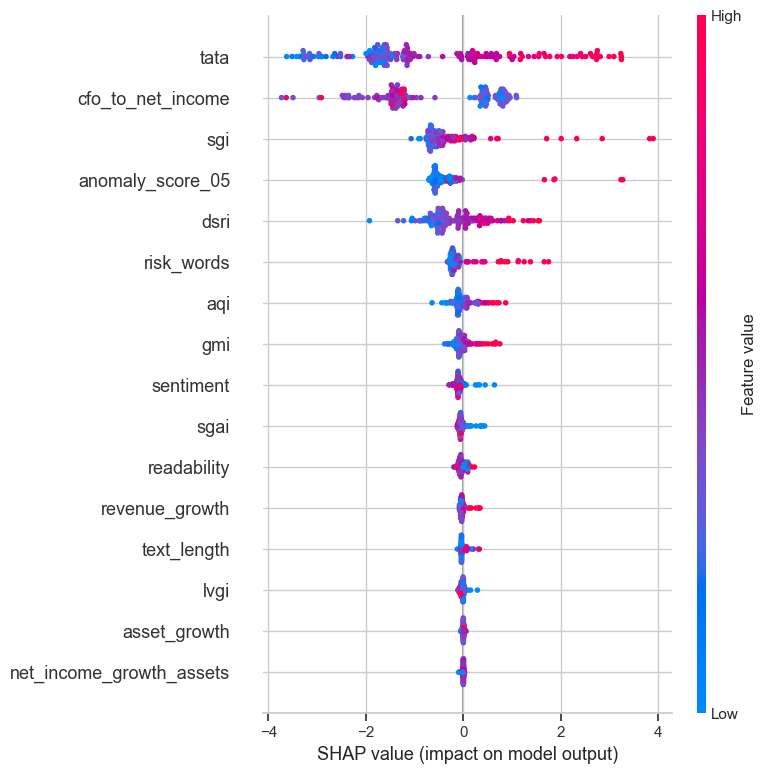

In [6]:
print("=== Global SHAP Summary Plot ===")
shap.summary_plot(
    shap_values,
    X_test,
    feature_names=features
)

## 4. Bar Summary Plot (Mempermudah Pemetaan ke Dashboard)

=== Global SHAP Feature Importance (Bar Plot) ===


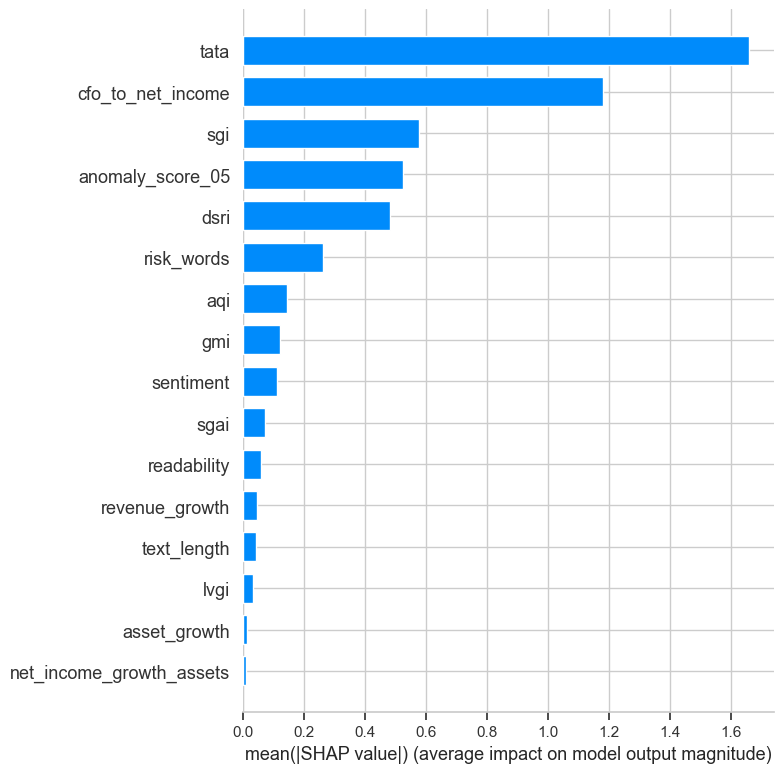

In [7]:
print("=== Global SHAP Feature Importance (Bar Plot) ===")
shap.summary_plot(
    shap_values,
    X_test,
    feature_names=features,
    plot_type="bar"
)

## 5. Local Explainability (Waterfall Plot)
Menganalisis pemicu risiko fraud pada tingkat perusahaan individual. Kita memilih emiten pada indeks tertentu untuk melihat bagaimana bias dasar (Base Value) digeser oleh masing-masing nilai fitur untuk menghasilkan probabilitas prediksi akhir.

=== Local SHAP Waterfall Plot (Sample Index 5) ===


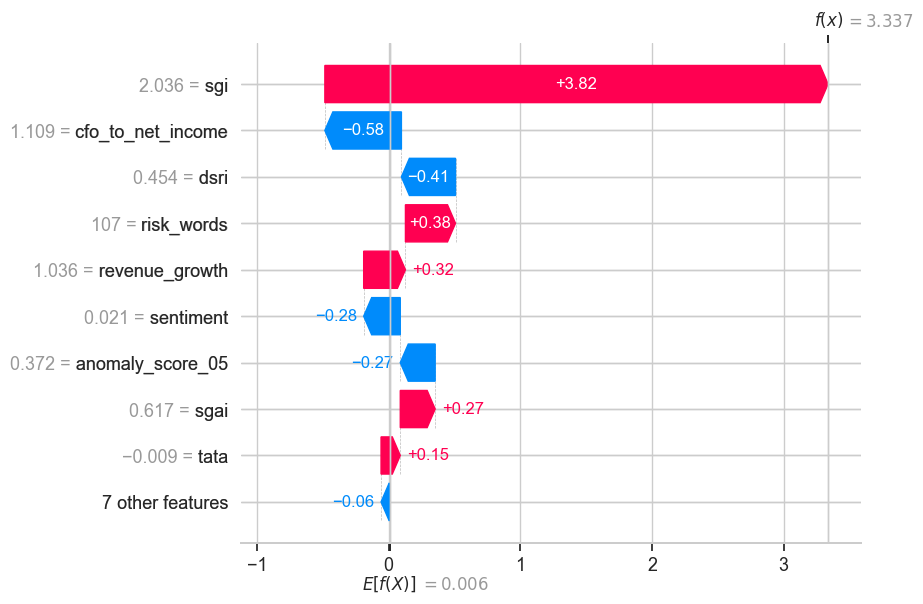

==== Global SHAP Beeswarm Plot ====


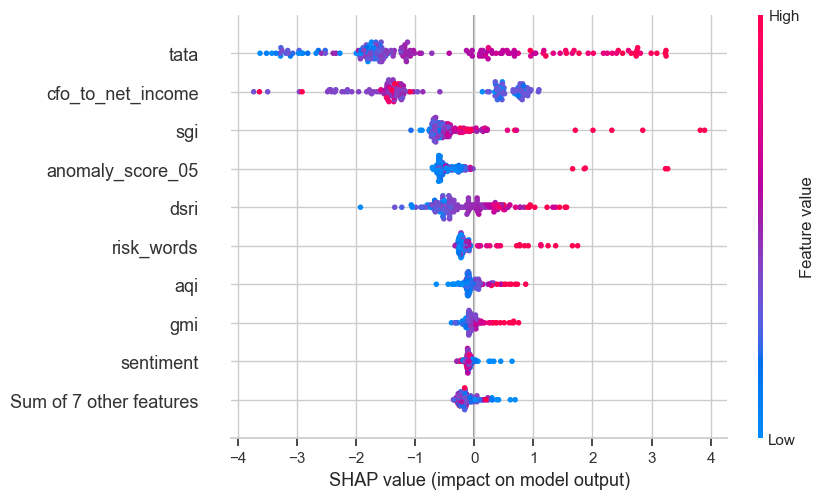

==== Global SHAP Bar Plot ====


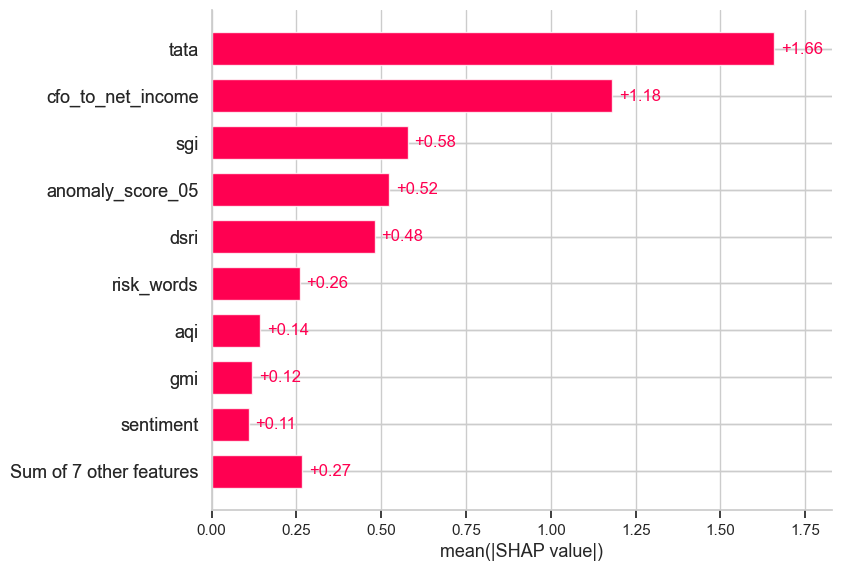

In [16]:
sample_idx = 5
print(f"=== Local SHAP Waterfall Plot (Sample Index {sample_idx}) ===")

shap_values_all = explainer(X_test)
shap.plots.waterfall(shap_values_all[sample_idx])
print("==== Global SHAP Beeswarm Plot ====")
shap.plots.beeswarm(shap_values_all)
print("==== Global SHAP Bar Plot ====")
shap.plots.bar(shap_values_all)

## 6. Mencari Top Driver Per Perusahaan
Kita akan mengekstrak kontribusi lokal dan mengurutkan fitur berdasarkan nilai absolut SHAP untuk menentukan 5 faktor pemicu utama (Top 5 Drivers) dari risiko fraud pada emiten tertentu.

In [22]:
sample = 0
shap_row = shap_values[sample]
sample_features = X_test.iloc[sample].values

# Membuat dataframe
if hasattr(shap_values, "values"):
    shap_row = shap_values.values[sample]
else:
    shap_row = shap_values[sample]

# Membuat dataframe
local_df = pd.DataFrame({
    "feature": features,
    "feature_value": sample_features,
    "shap_value": shap_row,
    "abs_shap": np.abs(shap_row)
})

local_df["impact"] = np.where(
    local_df["shap_value"] > 0,
    "increase",
    "decrease"
)

# Mengurutkan berdasarkan pengaruh terbesar
local_df = local_df.sort_values("abs_shap", ascending=False)

# Ambil 5 teratas
top5 = local_df.head(5)

print(f"=== Top 5 Drivers untuk Sampel Indeks {sample} ===")
for idx, r in top5.iterrows():
    print(f"{r['feature']} -> {r['shap_value']:.4f}")

=== Top 5 Drivers untuk Sampel Indeks 0 ===
tata -> -1.6647
cfo_to_net_income -> -1.5951
anomaly_score_05 -> -0.5588
sgi -> -0.3111
aqi -> 0.2904


## 7. Konversi Dataframe Audit ke JSON untuk API

In [23]:
# Contoh konversi hasil top drivers ke struktur JSON yang ramah Laravel/FastAPI
json_output = top5.to_json(orient="records", indent=2)
print("=== Output JSON untuk Integrasi Laravel / FastAPI ===")
print(json_output)

=== Output JSON untuk Integrasi Laravel / FastAPI ===
[
  {
    "feature":"tata",
    "feature_value":-0.080110332,
    "shap_value":-1.6647295952,
    "abs_shap":1.6647295952,
    "impact":"decrease"
  },
  {
    "feature":"cfo_to_net_income",
    "feature_value":1.4645317282,
    "shap_value":-1.5950593948,
    "abs_shap":1.5950593948,
    "impact":"decrease"
  },
  {
    "feature":"anomaly_score_05",
    "feature_value":0.3905793507,
    "shap_value":-0.5588188171,
    "abs_shap":0.5588188171,
    "impact":"decrease"
  },
  {
    "feature":"sgi",
    "feature_value":1.414596547,
    "shap_value":-0.3110997677,
    "abs_shap":0.3110997677,
    "impact":"decrease"
  },
  {
    "feature":"aqi",
    "feature_value":1.9266320291,
    "shap_value":0.290378958,
    "abs_shap":0.290378958,
    "impact":"increase"
  }
]


## 8. Fondasi Fraud Prediction API (FastAPI)
Berikut adalah struktur kode untuk menjalankan REST API pendeteksian fraud menggunakan FastAPI. 

Kode ini menerima payload 16 fitur emiten, melakukan klasifikasi probabilitas fraud, menghitung SHAP secara on-the-fly, mengekstrak Top 5 Drivers, dan mengembalikan respon berformat JSON.

In [24]:
from fastapi import FastAPI
from pydantic import BaseModel
import uvicorn

app = FastAPI(
    title="EWS Fraud Prediction API",
    description="API untuk memprediksi risiko fraud emiten berdasarkan analisis keuangan dan tekstual dengan penjelasan SHAP.",
    version="1.0.0"
)

# Schema Input Payload
class PredictionInput(BaseModel):
    dsri: float
    gmi: float
    aqi: float
    sgi: float
    lvgi: float
    tata: float
    sgai: float
    revenue_growth: float
    asset_growth: float
    net_income_growth_assets: float
    cfo_to_net_income: float
    sentiment: float
    risk_words: float
    readability: float
    text_length: float
    anomaly_score_05: float

@app.post("/predict")
def predict_fraud(input_data: PredictionInput):
    # 1. Konversi input ke format array / DataFrame
    input_dict = input_data.model_dump()
    input_df = pd.DataFrame([input_dict])
    
    # 2. Lakukan Prediksi
    prob = float(model.predict_proba(input_df)[0, 1])
    pred = int(model.predict(input_df)[0])
    
    # 3. Hitung SHAP secara dinamis
    inst_shap = explainer.shap_values(input_df)[0]
    
    # 4. Cari Top 5 Drivers
    local_df = pd.DataFrame({
        "feature": features,
        "shap_value": inst_shap,
        "abs_shap": np.abs(inst_shap)
    }).sort_values("abs_shap", ascending=False)
    
    top_drivers = local_df.head(5).to_dict(orient="records")
    
    return {
        "fraud_prediction": pred,
        "fraud_probability": prob,
        "top_drivers": top_drivers
    }

print("FastAPI App structure defined. Untuk menjalankan di terminal, gunakan command:")
print("uvicorn app:app --reload")

FastAPI App structure defined. Untuk menjalankan di terminal, gunakan command:
uvicorn app:app --reload
